# Interpolation and waveform scaling

Compare a reference waveform with a sampled signal, then scale the reference by trial mass and distance.

## Scientific method



The reference waveform is sampled on a much finer time grid than the mock observation. Interpolation maps the reference model onto the observation's sampling times, allowing point-by-point residuals to be calculated. The residual should be consistent with the mock signal's noise rather than reproducing the raw noise realization.

In [ ]:
from pathlib import Path

import sys



import matplotlib.pyplot as plt

import numpy as np

from scipy.stats import ks_2samp



PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / 'data').exists():

    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))



from gravitational_wave_mcmc import interpolate_waveform, load_waveform, scale_waveform

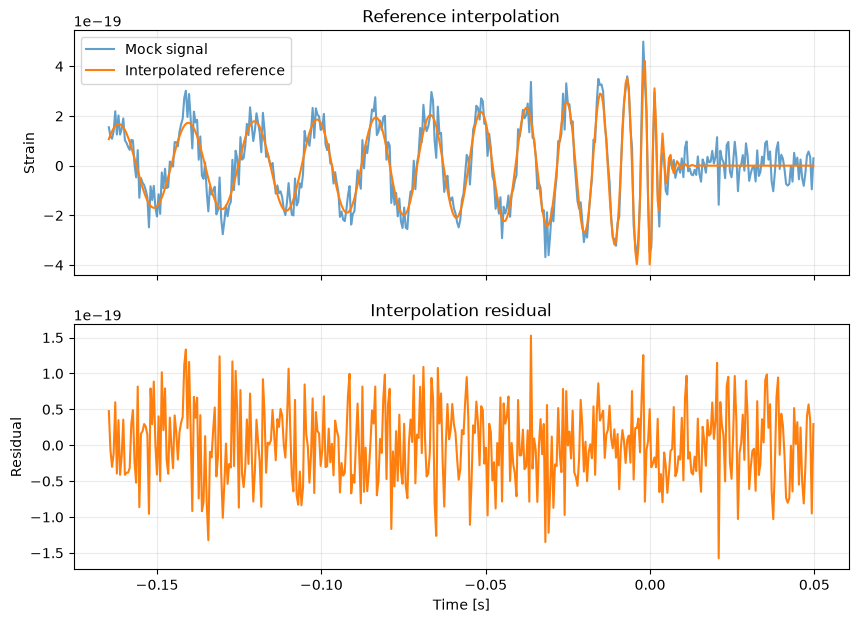

In [ ]:
#Load reference and mock waveforms, interpolate reference to mock time, and compute residual
reference = load_waveform(PROJECT_ROOT / 'data' / 'raw' / 'reference_waveform_40Msun_1Mpc.csv')
mock = load_waveform(PROJECT_ROOT / 'data' / 'raw' / 'mockdata_waveform_40Msun_1Mpc.csv')
interpolated = interpolate_waveform(reference, mock.time)
residual = mock.strain - interpolated

#Plot the reference, mock, and residual waveforms
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(mock.time, mock.strain, label='Mock signal', alpha=0.7)
axes[0].plot(mock.time, interpolated, label='Interpolated reference', lw=1.5)
axes[0].set(ylabel='Strain', title='Reference interpolation')
axes[0].legend()
axes[1].plot(mock.time, residual, color='tab:orange')
axes[1].set(xlabel='Time [s]', ylabel='Residual', title='Interpolation residual')
for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

## Residual check



The residual plot is the key diagnostic: phase agreement and residuals centred near zero indicate that interpolation has preserved the reference signal. The residual amplitude is expected to be comparable to the mock noise. A visual match alone is insufficient, so the residual distribution should also be summarised with a quantitative goodness-of-fit statistic.

In [9]:
#Identify the pre-merger portion of the waveform
pre_merger = np.isfinite(interpolated) & (mock.time < 0)

#Identify the post-merger noise portion of the waveform
mock_noise = mock.strain[mock.time >= 0.02]

#Compute goodness-of-fit metrics for the pre-merger portion of the waveform
residual_rmse = np.sqrt(np.mean(residual[pre_merger] ** 2))
residual_std = np.std(residual[pre_merger])
ks_result = ks_2samp(mock.strain[pre_merger], interpolated[pre_merger])

#Print a summary of the goodness-of-fit metrics
print('Goodness-of-fit is evaluated only before merger, where the reference model is defined.')
print(f'Residual RMSE: {residual_rmse:.3e}')
print(f'Residual standard deviation: {residual_std:.3e}')
print(f'Mock post-merger noise standard deviation: {np.std(mock_noise):.3e}')
print(f'KS statistic: {ks_result.statistic:.3f}')
print(f'KS p-value: {ks_result.pvalue:.4f}')

Goodness-of-fit is evaluated only before merger, where the reference model is defined.
Residual RMSE: 5.363e-20
Residual standard deviation: 5.361e-20
Mock post-merger noise standard deviation: 6.030e-20
KS statistic: 0.059
KS p-value: 0.5956


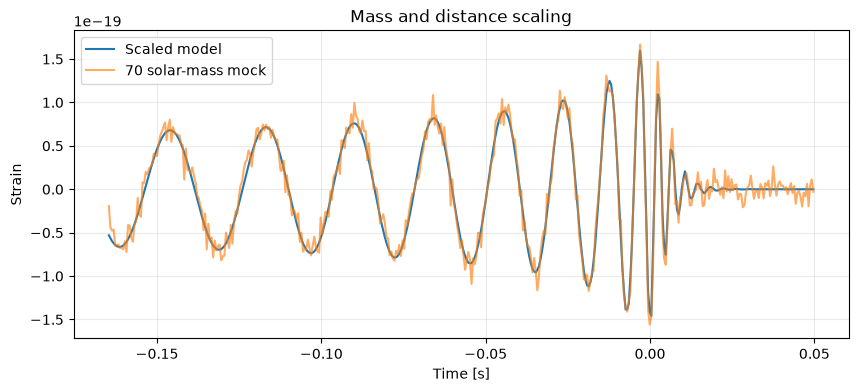

In [10]:
#Load the target waveform and scale the reference waveform to match its mass and distance   
target = load_waveform(PROJECT_ROOT / 'data' / 'raw' / 'mockdata_waveform_70Msun_5Mpc.csv')
scaled = scale_waveform(target.time, reference, reference_mass=40, reference_distance=1, mass=70, distance=5)

#Plot the scaled model against the target waveform
plt.figure(figsize=(10, 4))
plt.plot(target.time, scaled, label='Scaled model')
plt.plot(target.time, target.strain, label='70 solar-mass mock', alpha=0.65)
plt.xlabel('Time [s]')
plt.ylabel('Strain')
plt.title('Mass and distance scaling')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Scaling interpretation



The model uses the compact-binary scaling relations



$$t_{\rm ref}=t\frac{M_{\rm ref}}{M},\qquad h(t;M,D)=\frac{M}{M_{\rm ref}}\frac{D_{\rm ref}}{D}h_{\rm ref}(t_{\rm ref}).$$



Changing mass changes the phase evolution, while changing distance changes the amplitude. The comparison plot therefore tests two distinct physical effects and provides an initial estimate for the MCMC prior centre.